# Centralized Machine Learning Unlearning Evaluation

## Unlearning Pipeline

### Pipeline:
1. **Train baseline model on ALL data** (full training set)
2. **Split data** into delete set (5%) and retain set (95%)
3. **Save split indices** for consistency across techniques
4. **Exact unlearning**: Retrain from scratch on retain set only
5. **Approximate unlearning**: Start from baseline → gradient ascent on delete set
6. **Compare**: How well did each method remove the influence of delete data?

### Evaluation Metrics:
- **Forgetting**: Delete set accuracy drop (Baseline → Unlearned)
- **Utility**: Retain set accuracy preservation
- **Privacy**: Membership Inference Attack (MIA)
- **Efficiency**: Time comparison vs exact retraining

In [162]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import time
import json
from datetime import datetime
import os
import sys

print("Libraries imported successfully")

Libraries imported successfully


In [163]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

SEED = 123
DELETE_RATIO = 0.05
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 15
LOSS_NAME = "CrossEntropyLoss"

# Set all random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cpu")

print(f"\n{'=' * 70}")
print("EXPERIMENT CONFIGURATION")
print(f"{'=' * 70}")
print(f"Seed:                    {SEED}")
print(f"Deletion ratio:          {DELETE_RATIO*100:.1f}%")
print(f"Batch size:              {BATCH_SIZE}")
print(f"Learning rate:           {LEARNING_RATE}")
print(f"Training epochs:         {TRAIN_EPOCHS}")
print(f"Loss:                    {LOSS_NAME}")
print(f"Device:                  {device}")
print(f"{'=' * 70}\n")


EXPERIMENT CONFIGURATION
Seed:                    123
Deletion ratio:          5.0%
Batch size:              64
Learning rate:           0.001
Training epochs:         15
Loss:                    CrossEntropyLoss
Device:                  cpu



In [164]:
# Plot saving setup (technique + seed + delete ratio)
TECHNIQUE_NAME = "gradient_ascent_and_gold"
seed_str = f"{SEED:04d}"
delete_ratio_str = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
plot_output_dir = f"../results/plots/{TECHNIQUE_NAME}_seed_{seed_str}_delete_{delete_ratio_str}"
os.makedirs(plot_output_dir, exist_ok=True)


def save_plot(fig, filename):
    filepath = os.path.join(plot_output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {filepath}")


print(f"Plot directory ready: {plot_output_dir}")

Plot directory ready: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05


In [165]:
# Standard MNIST preprocessing (official normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST official mean/std
])

print("Loading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Full training data:      {len(train_dataset)}")
print(f"Holdout test data:       {len(test_dataset)}")
print(f"\nNote: Baseline model will be trained on ALL {len(train_dataset)} samples")

Loading MNIST dataset...
Full training data:      60000
Holdout test data:       10000

Note: Baseline model will be trained on ALL 60000 samples


In [166]:
class SimpleCNN(nn.Module):
    """Simple CNN for MNIST classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(5408, 10)
        )

    def forward(self, x):
        return self.net(x)

In [167]:
def train(model, loader, epochs=1, device=torch.device("cpu"), verbose=True):
    """Train model on a dataloader."""
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 100 == 0:
                print(f"Epoch [{epoch}/{epochs}], Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}")

        avg_epoch_loss = running_loss / len(loader)
        if verbose:
            print(f"--- Epoch {epoch} completed. Avg Loss: {avg_epoch_loss:.4f} ---")


def evaluate(model, loader, device=torch.device("cpu")):
    """Evaluate model accuracy and loss on a dataloader."""
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss_sum += criterion(outputs, y).item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct/total, loss_sum/len(loader)


def gradient_ascent_unlearning(model, delete_loader, lr=1e-4, steps=1, device=torch.device("cpu"), verbose=True):
    """Perform gradient-ascent unlearning on delete set."""
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for step in range(1, steps+1):
        running_loss = 0.0
        for batch_idx, (x, y) in enumerate(delete_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            (-loss).backward()  # gradient ASCENT (maximize loss on delete data)
            optimizer.step()
            running_loss += loss.item()

            if verbose and (batch_idx + 1) % 50 == 0:
                print(f"Step [{step}/{steps}], Batch [{batch_idx+1}/{len(delete_loader)}], Loss: {loss.item():.4f}")

        avg_loss = running_loss / len(delete_loader)
        if verbose:
            print(f"--- Step {step} completed. Avg Loss on deleted data: {avg_loss:.4f} ---")

In [168]:
# Import Membership Inference Attack (MIA) from separate module
sys.path.insert(0, '/Users/new/Desktop/unlearning')  # Add current notebook directory to path
from mia import evaluate_mia

## Stage 1: Train BASELINE Model on ALL Data

In [169]:
print("\n" + "="*70)
print("STAGE 1: BASELINE MODEL - Train on ALL data")
print("="*70)

# Create dataloader for FULL training set
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

baseline_model = SimpleCNN().to(device)
print("\nModel architecture:")
print(baseline_model)


STAGE 1: BASELINE MODEL - Train on ALL data

Model architecture:
SimpleCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=5408, out_features=10, bias=True)
  )
)


In [170]:
print(f"\nTraining baseline model on ALL {len(train_dataset)} samples for {TRAIN_EPOCHS} epoch(s)...")
print("(Including data that will later be marked for deleting)\n")
start = time.time()
train(baseline_model, full_train_loader, epochs=TRAIN_EPOCHS, device=device)
baseline_train_time = time.time() - start
print(f"\nBaseline training completed in {baseline_train_time:.2f} seconds")


Training baseline model on ALL 60000 samples for 15 epoch(s)...
(Including data that will later be marked for deleting)

Epoch [1/15], Batch [100/938], Loss: 0.2873
Epoch [1/15], Batch [200/938], Loss: 0.3500
Epoch [1/15], Batch [300/938], Loss: 0.0393
Epoch [1/15], Batch [400/938], Loss: 0.0353
Epoch [1/15], Batch [500/938], Loss: 0.0884
Epoch [1/15], Batch [600/938], Loss: 0.0700
Epoch [1/15], Batch [700/938], Loss: 0.0429
Epoch [1/15], Batch [800/938], Loss: 0.0791
Epoch [1/15], Batch [900/938], Loss: 0.0345
--- Epoch 1 completed. Avg Loss: 0.1780 ---
Epoch [2/15], Batch [100/938], Loss: 0.1366
Epoch [2/15], Batch [200/938], Loss: 0.0642
Epoch [2/15], Batch [300/938], Loss: 0.1352
Epoch [2/15], Batch [400/938], Loss: 0.1185
Epoch [2/15], Batch [500/938], Loss: 0.0768
Epoch [2/15], Batch [600/938], Loss: 0.1463
Epoch [2/15], Batch [700/938], Loss: 0.0288
Epoch [2/15], Batch [800/938], Loss: 0.0209
Epoch [2/15], Batch [900/938], Loss: 0.2269
--- Epoch 2 completed. Avg Loss: 0.0700 --

## Stage 2: Split Data & Save Indices

In [171]:
print("\n" + "="*70)
print("STAGE 2: SPLIT DATA & SAVE INDICES")
print("="*70)

# Split training data: delete (to forget) and retain (to keep)
num_delete = int(DELETE_RATIO * len(train_dataset))
num_retain = len(train_dataset) - num_delete

indices = np.random.permutation(len(train_dataset))
delete_idx = sorted(indices[:num_delete])
retain_idx = sorted(indices[num_delete:])

retain_set = Subset(train_dataset, retain_idx)
delete_set = Subset(train_dataset, delete_idx)

print(f"\nData Split:")
print(f"  Retain set (keep):   {len(retain_set):6d} samples ({len(retain_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Delete set (forget): {len(delete_set):6d} samples ({len(delete_set)/len(train_dataset)*100:5.1f}%)")
print(f"  Test set (holdout):  {len(test_dataset):6d} samples")

# Create dataloaders
retain_loader = DataLoader(retain_set, batch_size=BATCH_SIZE, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=BATCH_SIZE, shuffle=True)

# Save split indices for reuse across techniques
os.makedirs("../data_splits", exist_ok=True)
split_file = f"../data_splits/split_seed_{SEED:04d}.npz"
np.savez(split_file, delete_idx=delete_idx, retain_idx=retain_idx)
print(f"\nSplit indices saved to: {split_file}")
print("(Can be reused for consistent evaluation across different unlearning techniques)")


STAGE 2: SPLIT DATA & SAVE INDICES

Data Split:
  Retain set (keep):    57000 samples ( 95.0%)
  Delete set (forget):   3000 samples (  5.0%)
  Test set (holdout):   10000 samples

Split indices saved to: ../data_splits/split_seed_0123.npz
(Can be reused for consistent evaluation across different unlearning techniques)


## Stage 3: Evaluate Baseline on All Sets

In [172]:
print("\n" + "="*70)
print("BASELINE PERFORMANCE (Before any unlearning)")
print("="*70)

# Evaluate baseline on all splits
retain_acc_before, retain_loss_before = evaluate(baseline_model, retain_loader, device)
delete_acc_before, delete_loss_before = evaluate(baseline_model, delete_loader, device)
test_acc_before, test_loss_before = evaluate(baseline_model, test_loader, device)

print(f"\nBaseline accuracy & loss:")
print(f"  Retain set:  Acc={retain_acc_before:.4f}, Loss={retain_loss_before:.4f}")
print(f"  Delete set:  Acc={delete_acc_before:.4f}, Loss={delete_loss_before:.4f}")
print(f"  Test set:    Acc={test_acc_before:.4f}, Loss={test_loss_before:.4f}")


BASELINE PERFORMANCE (Before any unlearning)

Baseline accuracy & loss:
  Retain set:  Acc=0.9982, Loss=0.0063
  Delete set:  Acc=0.9993, Loss=0.0050
  Test set:    Acc=0.9836, Loss=0.0700


## Stage 4A: Exact Unlearning - Retrain from Scratch

In [173]:
print("\n" + "="*70)
print("STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only")
print("="*70)

exact_model = SimpleCNN().to(device)
print(f"\nTraining exact model from scratch on ONLY retain set ({len(retain_set)} samples)...")
print("(This model NEVER sees delete data = ground truth unlearning)\n")

start = time.time()
train(exact_model, retain_loader, epochs=TRAIN_EPOCHS, device=device)
exact_time = time.time() - start
print(f"\nExact unlearning completed in {exact_time:.2f} seconds")


STAGE 4A: EXACT UNLEARNING - Retrain from scratch on RETAIN only

Training exact model from scratch on ONLY retain set (57000 samples)...
(This model NEVER sees delete data = ground truth unlearning)

Epoch [1/15], Batch [100/891], Loss: 0.3112
Epoch [1/15], Batch [200/891], Loss: 0.1815
Epoch [1/15], Batch [300/891], Loss: 0.3027
Epoch [1/15], Batch [400/891], Loss: 0.1294
Epoch [1/15], Batch [500/891], Loss: 0.0552
Epoch [1/15], Batch [600/891], Loss: 0.1226
Epoch [1/15], Batch [700/891], Loss: 0.1156
Epoch [1/15], Batch [800/891], Loss: 0.1373
--- Epoch 1 completed. Avg Loss: 0.1895 ---
Epoch [2/15], Batch [100/891], Loss: 0.0993
Epoch [2/15], Batch [200/891], Loss: 0.0263
Epoch [2/15], Batch [300/891], Loss: 0.0625
Epoch [2/15], Batch [400/891], Loss: 0.0239
Epoch [2/15], Batch [500/891], Loss: 0.0257
Epoch [2/15], Batch [600/891], Loss: 0.0734
Epoch [2/15], Batch [700/891], Loss: 0.0604
Epoch [2/15], Batch [800/891], Loss: 0.0581
--- Epoch 2 completed. Avg Loss: 0.0740 ---
Epoch 

In [174]:
# Evaluate exact model
exact_retain_acc, exact_retain_loss = evaluate(exact_model, retain_loader, device)
exact_delete_acc, exact_delete_loss = evaluate(exact_model, delete_loader, device)
exact_test_acc, exact_test_loss = evaluate(exact_model, test_loader, device)

print(f"\nExact model performance:")
print(f"  Retain set:  Acc={exact_retain_acc:.4f}, Loss={exact_retain_loss:.4f}")
print(f"  Delete set:  Acc={exact_delete_acc:.4f}, Loss={exact_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={exact_test_acc:.4f}, Loss={exact_test_loss:.4f}")


Exact model performance:
  Retain set:  Acc=0.9990, Loss=0.0044
  Delete set:  Acc=0.9820, Loss=0.0716  <- Should be LOW (forgotten)
  Test set:    Acc=0.9826, Loss=0.0738


## Stage 4B: Approximate Unlearning - Gradient Ascent

In [175]:
print("\n" + "="*70)
print("STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set")
print("="*70)

approx_model = SimpleCNN().to(device)
approx_model.load_state_dict(baseline_model.state_dict())  # Start from baseline
print(f"\nStarting with baseline (trained on ALL data)")
print(f"Applying gradient ascent to MAXIMIZE loss on delete set...\n")

start_time = time.time()
gradient_ascent_unlearning(approx_model, delete_loader, lr=1e-4, steps=3, device=device)
approx_time = time.time() - start_time

print(f"\nApproximate unlearning completed in {approx_time:.2f} seconds")


STAGE 4B: APPROXIMATE UNLEARNING - Gradient ascent on delete set

Starting with baseline (trained on ALL data)
Applying gradient ascent to MAXIMIZE loss on delete set...

--- Step 1 completed. Avg Loss on deleted data: 0.0048 ---
--- Step 2 completed. Avg Loss on deleted data: 0.0049 ---
--- Step 3 completed. Avg Loss on deleted data: 0.0049 ---

Approximate unlearning completed in 2.06 seconds


In [176]:
# Evaluate approximate model
approx_retain_acc, approx_retain_loss = evaluate(approx_model, retain_loader, device)
approx_delete_acc, approx_delete_loss = evaluate(approx_model, delete_loader, device)
approx_test_acc, approx_test_loss = evaluate(approx_model, test_loader, device)

print(f"\nApproximate model performance:")
print(f"  Retain set:  Acc={approx_retain_acc:.4f}, Loss={approx_retain_loss:.4f}  <- Should be HIGH (preserved)")
print(f"  Delete set:  Acc={approx_delete_acc:.4f}, Loss={approx_delete_loss:.4f}  <- Should be LOW (forgotten)")
print(f"  Test set:    Acc={approx_test_acc:.4f}, Loss={approx_test_loss:.4f}")


Approximate model performance:
  Retain set:  Acc=0.9982, Loss=0.0063  <- Should be HIGH (preserved)
  Delete set:  Acc=0.9993, Loss=0.0049  <- Should be LOW (forgotten)
  Test set:    Acc=0.9836, Loss=0.0701


## Stage 5: Comprehensive Evaluation

In [177]:
# Model distance
# def model_distance(model1, model2):
#     total = 0
#     for p1, p2 in zip(model1.parameters(), model2.parameters()):
#         total += torch.norm(p1 - p2).item()
#     return total

# distance_to_exact = model_distance(approx_model, exact_model)
def model_distance_metrics(approx_model, exact_model):
    sq_diff = 0.0
    sq_exact = 0.0
    
    for p_approx, p_exact in zip(approx_model.parameters(), exact_model.parameters()):
        # Sum of squared differences: ||theta_approx - theta_exact||^2
        sq_diff += torch.sum((p_approx - p_exact) ** 2)
        
        # Sum of squared magnitudes of the exact model: ||theta_exact||^2
        sq_exact += torch.sum(p_exact ** 2)
    
    abs_dist = torch.sqrt(sq_diff).item()
    norm_exact = torch.sqrt(sq_exact).item()
    
    # Relative distance: ||diff|| / ||exact||
    rel_dist = abs_dist / (norm_exact + 1e-12) # epsilon for stability
    
    return abs_dist, rel_dist

# Usage
abs_l2, rel_l2 = model_distance_metrics(approx_model, exact_model)

print(f"Absolute L2 Distance: {abs_l2:.4f}")
print(f"Relative Distance:    {rel_l2:.4%}") # Formats as a percentage

print("\n" + "="*70)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("="*70)

summary_data = {
    "Metric": [
        "DELETE ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Forgetting (Exact)",
        "  Forgetting (Approx)",
        "",
        "RETAIN ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "  Utility Loss (Approx)",
        "",
        "TEST ACCURACY:",
        "  Baseline",
        "  Exact",
        "  Approx",
        "",
        "MODEL DISTANCE (UNLEARNING QUALITY):",
        "  Abs. L2 Distance ||W_app - W_ex||₂",
        "  Rel. L2 Distance (Error %)",
        "",
        "EFFICIENCY:",
        "  Exact time (seconds)",
        "  Approx time (seconds)",
        "  Speedup factor"
    ],
    "Value": [
        "",
        f"{delete_acc_before:.4f}",
        f"{exact_delete_acc:.4f}",
        f"{approx_delete_acc:.4f}",
        f"{delete_acc_before - exact_delete_acc:.4f}",
        f"{delete_acc_before - approx_delete_acc:.4f}",
        "",
        "",
        f"{retain_acc_before:.4f}",
        f"{exact_retain_acc:.4f}",
        f"{approx_retain_acc:.4f}",
        f"{retain_acc_before - approx_retain_acc:.4f}",
        "",
        "",
        f"{test_acc_before:.4f}",
        f"{exact_test_acc:.4f}",
        f"{approx_test_acc:.4f}",
        "",
        "",
        f"{abs_l2:.4f}",
        f"{rel_l2:.4%}",
        "",
        "",
        f"{exact_time:.2f}s",
        f"{approx_time:.2f}s",
        f"{exact_time/approx_time:.1f}x faster"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

Absolute L2 Distance: 38.6585
Relative Distance:    135.5529%

COMPREHENSIVE EVALUATION SUMMARY

                              Metric        Value
                    DELETE ACCURACY:             
                            Baseline       0.9993
                               Exact       0.9820
                              Approx       0.9993
                  Forgetting (Exact)       0.0173
                 Forgetting (Approx)       0.0000
                                                 
                    RETAIN ACCURACY:             
                            Baseline       0.9982
                               Exact       0.9990
                              Approx       0.9982
               Utility Loss (Approx)       0.0000
                                                 
                      TEST ACCURACY:             
                            Baseline       0.9836
                               Exact       0.9826
                              Approx       0.9836
   

## Stage 6: Privacy Evaluation - Membership Inference Attack

In [178]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL")
print("="*70)
print("\nCan an attacker tell if data was in training set?")
print(f"Members:     retain_loader (in training)")
print(f"Non-members: delete_loader (in training)")
print("\nNote: Both are 'members' since baseline was trained on ALL data.")
print("      This shows the baseline's baseline vulnerability.\n")

mia_baseline = evaluate_mia(baseline_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_baseline['mia_accuracy']:.4f}")
print(f"  (How well can attacker distinguish retain vs delete?)")
print(f"True Positive Rate (TPR): {mia_baseline['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_baseline['fpr']:.4f}")


MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL

Can an attacker tell if data was in training set?
Members:     retain_loader (in training)
Non-members: delete_loader (in training)

Note: Both are 'members' since baseline was trained on ALL data.
      This shows the baseline's baseline vulnerability.

MIA Accuracy:             0.8989
  (How well can attacker distinguish retain vs delete?)
True Positive Rate (TPR): 0.9433
False Positive Rate (FPR):0.9460


In [179]:
print("\n" + "="*70)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING")
print("="*70)
print("\nCan attacker still distinguish retain vs delete samples?")
print("If unlearning works, delete samples should look 'unknown' to the model.\n")

mia_approx = evaluate_mia(approx_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_approx['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_approx['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_approx['fpr']:.4f}")

privacy_gain = mia_baseline['mia_accuracy'] - mia_approx['mia_accuracy']
print(f"\nPrivacy Gain: {privacy_gain:+.4f}  (Positive = Better)")


MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING

Can attacker still distinguish retain vs delete samples?
If unlearning works, delete samples should look 'unknown' to the model.

MIA Accuracy:             0.8988
True Positive Rate (TPR): 0.9432
False Positive Rate (FPR):0.9460

Privacy Gain: +0.0001  (Positive = Better)


## Stage 6A: Per-Class Accuracy & Confusion Matrices

In [180]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix_and_per_class_metrics(model, loader, device=torch.device("cpu")):
    """
    Compute confusion matrix and per-class accuracy metrics.
    
    Returns:
        cm: Confusion matrix (10x10 for MNIST)
        per_class_acc: Dictionary with per-class accuracy for each digit
        y_true_all: All true labels
        y_pred_all: All predicted labels
    """
    model.eval()
    y_true_all = []
    y_pred_all = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true_all.extend(y.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())
    
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(10))
    
    # Compute per-class accuracy
    per_class_acc = {}
    for digit in range(10):
        mask = (y_true_all == digit)
        if mask.sum() > 0:
            acc = (y_pred_all[mask] == digit).sum() / mask.sum()
            per_class_acc[digit] = acc
        else:
            per_class_acc[digit] = None
    
    return cm, per_class_acc, y_true_all, y_pred_all


def plot_confusion_matrix(cm, title, ax=None, cmap='Blues'):
    """Plot confusion matrix as heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, 
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title, fontsize=12, fontweight='bold')
    return ax


print("Confusion matrix and per-class metrics functions loaded")

Confusion matrix and per-class metrics functions loaded



BASELINE MODEL - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Digit 0: 0.9995
  Digit 1: 0.9988
  Digit 2: 1.0000
  Digit 3: 0.9950
  Digit 4: 0.9971
  Digit 5: 0.9994
  Digit 6: 1.0000
  Digit 7: 0.9978
  Digit 8: 0.9959
  Digit 9: 0.9984
Saved plot: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05/plot_01_baseline_confusion_matrix_retain.png


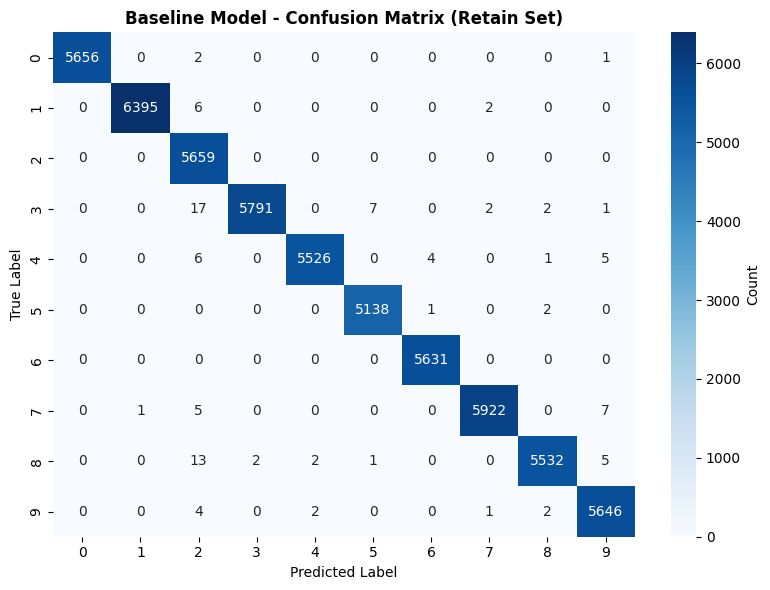

In [181]:
print("\n" + "="*70)
print("BASELINE MODEL - Per-Class Accuracy & Confusion Matrix")
print("="*70)

baseline_cm, baseline_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(10):
    acc = baseline_per_class[digit]
    if acc is not None:
        print(f"  Digit {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion_matrix(baseline_cm, "Baseline Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_01_baseline_confusion_matrix_retain.png")
plt.show()


EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Digit 0: 0.9991
  Digit 1: 1.0000
  Digit 2: 0.9995
  Digit 3: 0.9995
  Digit 4: 0.9987
  Digit 5: 0.9979
  Digit 6: 1.0000
  Digit 7: 0.9988
  Digit 8: 0.9978
  Digit 9: 0.9981
Saved plot: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05/plot_02_exact_confusion_matrix_retain.png


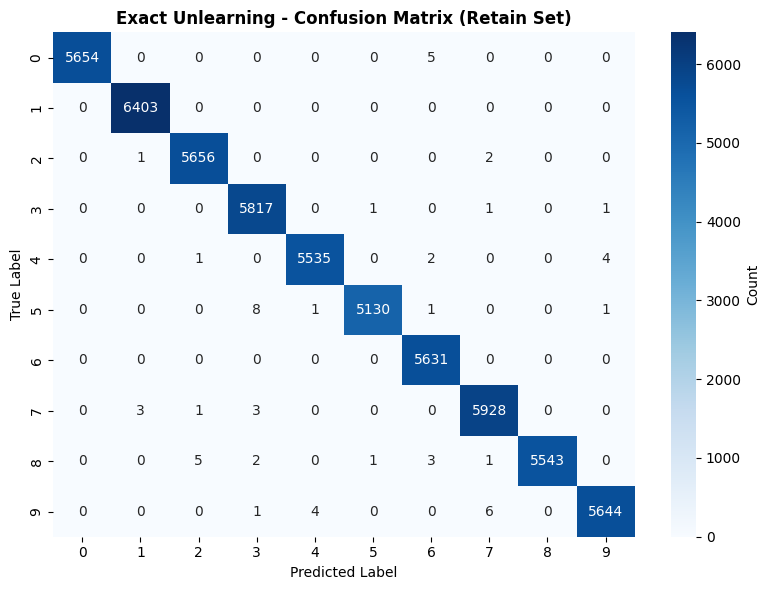

In [182]:
print("\n" + "="*70)
print("EXACT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

exact_cm, exact_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(10):
    acc = exact_per_class[digit]
    if acc is not None:
        print(f"  Digit {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion_matrix(exact_cm, "Exact Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_02_exact_confusion_matrix_retain.png")
plt.show()


GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Digit 0: 0.9995
  Digit 1: 0.9988
  Digit 2: 1.0000
  Digit 3: 0.9950
  Digit 4: 0.9971
  Digit 5: 0.9994
  Digit 6: 1.0000
  Digit 7: 0.9978
  Digit 8: 0.9957
  Digit 9: 0.9984
Saved plot: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05/plot_03_gradient_ascent_confusion_matrix_retain.png


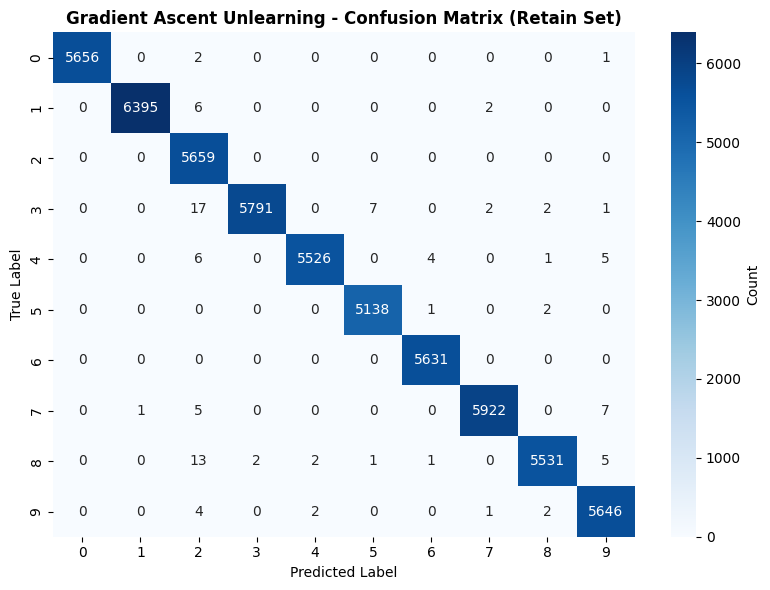

In [183]:
print("\n" + "="*70)
print("GRADIENT ASCENT UNLEARNING - Per-Class Accuracy & Confusion Matrix")
print("="*70)

approx_cm, approx_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for digit in range(10):
    acc = approx_per_class[digit]
    if acc is not None:
        print(f"  Digit {digit}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion_matrix(approx_cm, "Gradient Ascent Unlearning - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_03_gradient_ascent_confusion_matrix_retain.png")
plt.show()

In [184]:
print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON (RETAIN SET)")
print("="*70)

# Create comparison dataframe
comparison_data = {
    'Digit': list(range(10)),
    'Baseline': [baseline_per_class[d] for d in range(10)],
    'Exact (Retrained)': [exact_per_class[d] for d in range(10)],
    'Approx (Grad Ascent)': [approx_per_class[d] for d in range(10)],
}

# Add utility loss (drop from baseline to approx)
comparison_data['Utility Loss (Approx)'] = [
    baseline_per_class[d] - approx_per_class[d] for d in range(10)
]

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Summary statistics
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy (RETAIN set):")
print(f"  Baseline:              {comparison_df['Baseline'].mean():.4f}")
print(f"  Exact (Retrained):     {comparison_df['Exact (Retrained)'].mean():.4f}")
print(f"  Approx (Grad Ascent):  {comparison_df['Approx (Grad Ascent)'].mean():.4f}")
print(f"\nAverage utility loss:    {comparison_df['Utility Loss (Approx)'].mean():.4f}")
print(f"Max utility loss (most affected class): Digit {comparison_df['Utility Loss (Approx)'].idxmax()} ({comparison_df['Utility Loss (Approx)'].max():.4f})")
print(f"Min utility loss (least affected class): Digit {comparison_df['Utility Loss (Approx)'].idxmin()} ({comparison_df['Utility Loss (Approx)'].min():.4f})")


PER-CLASS ACCURACY COMPARISON (RETAIN SET)

 Digit  Baseline  Exact (Retrained)  Approx (Grad Ascent)  Utility Loss (Approx)
     0  0.999470           0.999116              0.999470                0.00000
     1  0.998751           1.000000              0.998751                0.00000
     2  1.000000           0.999470              1.000000                0.00000
     3  0.995017           0.999485              0.995017                0.00000
     4  0.997113           0.998737              0.997113                0.00000
     5  0.999416           0.997860              0.999416                0.00000
     6  1.000000           1.000000              1.000000                0.00000
     7  0.997810           0.998821              0.997810                0.00000
     8  0.995860           0.997840              0.995680                0.00018
     9  0.998408           0.998055              0.998408                0.00000

SUMMARY

Average per-class accuracy (RETAIN set):
  Baseline:  

In [185]:
print("\n" + "="*70)
print("DELETE SET PERFORMANCE - Per-Class Accuracy")
print("="*70)
print("\nForgetting Score: How much baseline accuracy decreased per class")
print("(Higher = better forgetting)")

# Compute per-class metrics on DELETE set
baseline_delete_cm, baseline_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_model, delete_loader, device
)
exact_delete_cm, exact_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    exact_model, delete_loader, device
)
approx_delete_cm, approx_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    approx_model, delete_loader, device
)

# Create comparison dataframe for DELETE set
delete_comparison_data = {
    'Digit': list(range(10)),
    'Baseline (Before)': [baseline_delete_pc[d] for d in range(10)],
    'Exact (After)': [exact_delete_pc[d] for d in range(10)],
    'Approx (After)': [approx_delete_pc[d] for d in range(10)],
}

# Forgetting scores
delete_comparison_data['Forgetting (Exact)'] = [
    baseline_delete_pc[d] - exact_delete_pc[d] for d in range(10)
]
delete_comparison_data['Forgetting (Approx)'] = [
    baseline_delete_pc[d] - approx_delete_pc[d] for d in range(10)
]

delete_comparison_df = pd.DataFrame(delete_comparison_data)
print("\n" + delete_comparison_df.to_string(index=False))

print("\n" + "="*70)
print("DELETE SET SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy on DELETE set:")
print(f"  Baseline (Before):     {delete_comparison_df['Baseline (Before)'].mean():.4f}")
print(f"  Exact (After):         {delete_comparison_df['Exact (After)'].mean():.4f}")
print(f"  Approx (After):        {delete_comparison_df['Approx (After)'].mean():.4f}")

print(f"\nAverage Forgetting Score:")
print(f"  Exact Method:          {delete_comparison_df['Forgetting (Exact)'].mean():.4f}")
print(f"  Approx Method:         {delete_comparison_df['Forgetting (Approx)'].mean():.4f}")

print(f"\nBest Forgetting (Approx): Digit {delete_comparison_df['Forgetting (Approx)'].idxmax()} ({delete_comparison_df['Forgetting (Approx)'].max():.4f})")
print(f"Worst Forgetting (Approx): Digit {delete_comparison_df['Forgetting (Approx)'].idxmin()} ({delete_comparison_df['Forgetting (Approx)'].min():.4f})")


DELETE SET PERFORMANCE - Per-Class Accuracy

Forgetting Score: How much baseline accuracy decreased per class
(Higher = better forgetting)

 Digit  Baseline (Before)  Exact (After)  Approx (After)  Forgetting (Exact)  Forgetting (Approx)
     0           0.996212       0.988636        0.996212            0.007576                  0.0
     1           1.000000       0.988201        1.000000            0.011799                  0.0
     2           1.000000       0.986622        1.000000            0.013378                  0.0
     3           1.000000       0.983923        1.000000            0.016077                  0.0
     4           1.000000       0.990000        1.000000            0.010000                  0.0
     5           1.000000       0.989286        1.000000            0.010714                  0.0
     6           1.000000       0.982578        1.000000            0.017422                  0.0
     7           0.996970       0.966667        0.996970            0.03030


CONFUSION MATRIX COMPARISON - All Three Techniques
Saved plot: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05/plot_04_confusion_matrix_comparison_retain.png


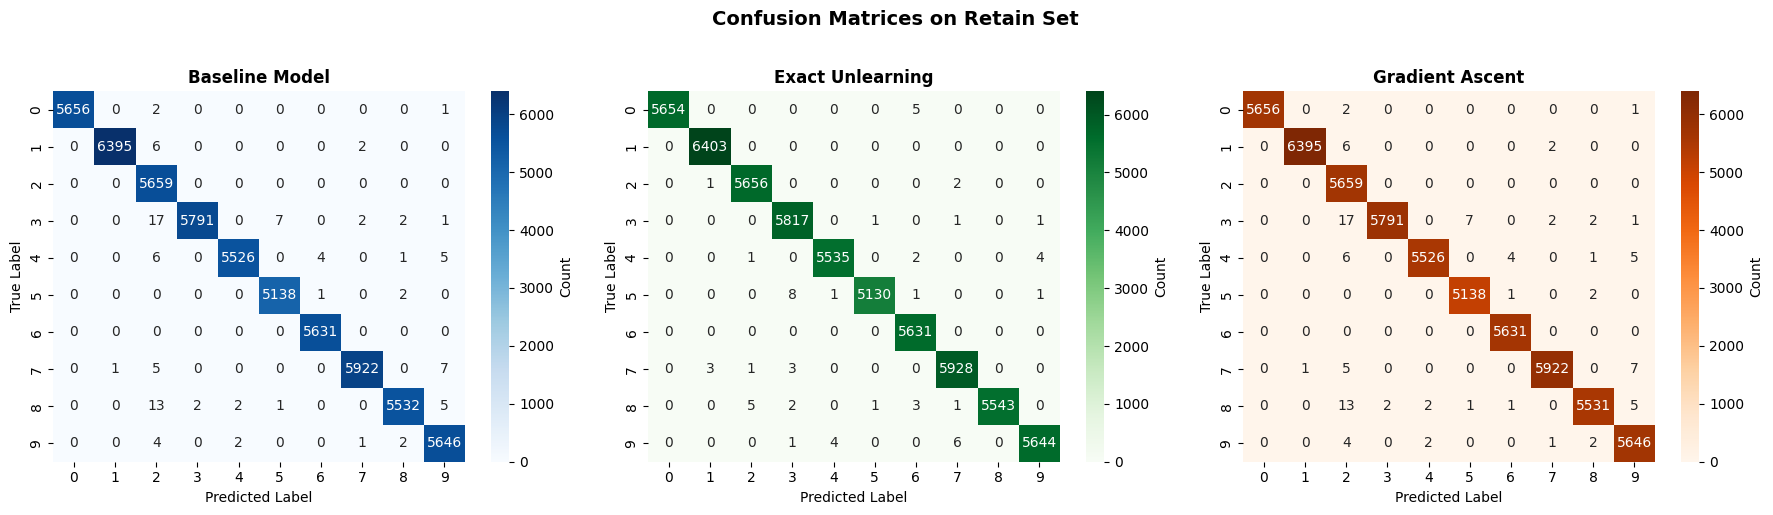

Confusion matrices visualized


In [186]:
print("\n" + "="*70)
print("CONFUSION MATRIX COMPARISON - All Three Techniques")
print("="*70)

# Create side-by-side confusion matrices (RETAIN set)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion_matrix(baseline_cm, "Baseline Model", ax=axes[0], cmap='Blues')
plot_confusion_matrix(exact_cm, "Exact Unlearning", ax=axes[1], cmap='Greens')
plot_confusion_matrix(approx_cm, "Gradient Ascent", ax=axes[2], cmap='Oranges')

plt.suptitle('Confusion Matrices on Retain Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot(fig, "plot_04_confusion_matrix_comparison_retain.png")
plt.show()

print("Confusion matrices visualized")


PER-CLASS ACCURACY VISUALIZATION (RETAIN SET)
Saved plot: ../results/plots/gradient_ascent_and_gold_seed_0123_delete_0p05/plot_05_per_class_accuracy_and_utility_loss.png


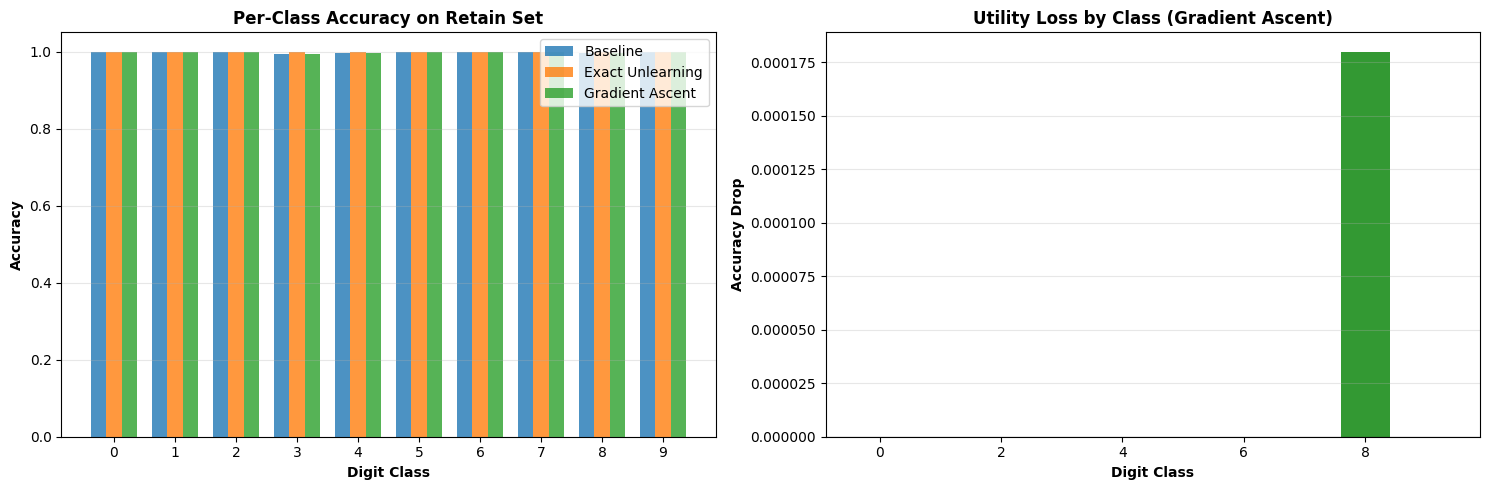

Per-class accuracy visualization complete


In [187]:
print("\nPER-CLASS ACCURACY VISUALIZATION (RETAIN SET)")

# Create bar chart comparing per-class accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Per-class accuracy for all three methods
digits = list(range(10))
x = np.arange(len(digits))
width = 0.25

baseline_accs = [baseline_per_class[d] for d in range(10)]
exact_accs = [exact_per_class[d] for d in range(10)]
approx_accs = [approx_per_class[d] for d in range(10)]

ax1.bar(x - width, baseline_accs, width, label='Baseline', alpha=0.8)
ax1.bar(x, exact_accs, width, label='Exact Unlearning', alpha=0.8)
ax1.bar(x + width, approx_accs, width, label='Gradient Ascent', alpha=0.8)

ax1.set_xlabel('Digit Class', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy on Retain Set', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(digits)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Utility Loss (how much each class dropped with gradient ascent)
utility_losses = [baseline_per_class[d] - approx_per_class[d] for d in range(10)]
colors = ['red' if loss > 0.05 else 'orange' if loss > 0.02 else 'green' for loss in utility_losses]
ax2.bar(digits, utility_losses, color=colors, alpha=0.8)

ax2.set_xlabel('Digit Class', fontweight='bold')
ax2.set_ylabel('Accuracy Drop', fontweight='bold')
ax2.set_title('Utility Loss by Class (Gradient Ascent)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
save_plot(fig, "plot_05_per_class_accuracy_and_utility_loss.png")
plt.show()

print("Per-class accuracy visualization complete")

## Stage 7: Save Results

In [188]:
results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "seed": SEED,
        "dataset": "MNIST",
        "model": "SimpleCNN",
        "deletion_ratio": DELETE_RATIO,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": TRAIN_EPOCHS,
        "loss": LOSS_NAME,
        "device": str(device),
        "important_note": "Baseline trained on ALL data, then split for evaluation"
    },

    "baseline_model": {
        "train_time_seconds": baseline_train_time,
        "trained_on": "All 60000 training samples",
        "delete_set_accuracy": float(delete_acc_before),
        "delete_set_loss": float(delete_loss_before),
        "retain_set_accuracy": float(retain_acc_before),
        "test_accuracy": float(test_acc_before),
        "per_class_accuracy": {
            "retain_set": {str(digit): float(baseline_per_class[digit]) for digit in range(10)},
            "delete_set": {str(digit): float(baseline_delete_pc[digit]) for digit in range(10)},
        },
    },

    "exact_unlearning": {
        "method": "Retrain from scratch on retain set only",
        "train_time_seconds": exact_time,
        "delete_set_accuracy": float(exact_delete_acc),
        "delete_set_loss": float(exact_delete_loss),
        "forgetting_score": float(delete_acc_before - exact_delete_acc),
        "retain_set_accuracy": float(exact_retain_acc),
        "test_accuracy": float(exact_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(digit): float(exact_per_class[digit]) for digit in range(10)},
            "delete_set": {str(digit): float(exact_delete_pc[digit]) for digit in range(10)},
        },
        "per_class_forgetting_score": {
            str(digit): float(baseline_delete_pc[digit] - exact_delete_pc[digit]) for digit in range(10)
        },
    },
    
    "approx_unlearning": {
        "method": "Gradient ascent on delete set",
        "hyperparameters": {
            "lr": 1e-4,
            "steps": 3,
            "optimizer": "SGD"
        },
        "train_time_seconds": approx_time,
        "delete_set_accuracy": float(approx_delete_acc),
        "delete_set_loss": float(approx_delete_loss),
        "forgetting_score": float(delete_acc_before - approx_delete_acc),
        "retain_set_accuracy": float(approx_retain_acc),
        "utility_loss": float(retain_acc_before - approx_retain_acc),
        "test_accuracy": float(approx_test_acc),
        "per_class_accuracy": {
            "retain_set": {str(digit): float(approx_per_class[digit]) for digit in range(10)},
            "delete_set": {str(digit): float(approx_delete_pc[digit]) for digit in range(10)},
        },
        "per_class_forgetting_score": {
            str(digit): float(baseline_delete_pc[digit] - approx_delete_pc[digit]) for digit in range(10)
        },
        "per_class_utility_loss": {
            str(digit): float(baseline_per_class[digit] - approx_per_class[digit]) for digit in range(10)
        },
        "distance_metrics": {
            "l2_absolute": float(abs_l2),
            "l2_relative": float(rel_l2),
            "metric_definition": "Global L2 norm over all parameters"
        },
    },

    "efficiency_comparison": {
        "exact_time_seconds": exact_time,
        "approx_time_seconds": approx_time,
        "speedup_factor": float(exact_time / approx_time),
    },

    "privacy_evaluation_mia": {
        "baseline_model": {
            "mia_accuracy": mia_baseline['mia_accuracy'],
            "tpr": mia_baseline['tpr'],
            "fpr": mia_baseline['fpr'],
        },
        "after_unlearning": {
            "mia_accuracy": mia_approx['mia_accuracy'],
            "tpr": mia_approx['tpr'],
            "fpr": mia_approx['fpr'],
        },
        "privacy_gain": float(privacy_gain),
    },

    "data_split_info": {
        "total_training_samples": len(train_dataset),
        "delete_set_size": len(delete_set),
        "retain_set_size": len(retain_set),
        "test_set_size": len(test_dataset),
        "split_saved_to": split_file,
    }
}

# Create output directories
os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Save model checkpoints
baseline_model_path = f"../models/baseline_seed_{SEED:04d}.pt"
gold_model_path = f"../models/gold_exact_seed_{SEED:04d}.pt"
approx_model_path = f"../models/approx_unlearned_seed_{SEED:04d}.pt"

torch.save(baseline_model.state_dict(), baseline_model_path)
torch.save(exact_model.state_dict(), gold_model_path)
torch.save(approx_model.state_dict(), approx_model_path)

# Add checkpoint paths to results
results["saved_models"] = {
    "baseline_model_path": baseline_model_path,
    "gold_model_path": gold_model_path,
    "approx_model_path": approx_model_path
}

# Save metrics JSON
filename = f"../results/metadata/unlearning_seed_{SEED:04d}_{DELETE_RATIO}_results.json"
with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n Results saved to: {filename}")
print(f" Data split saved to: {split_file}")
print(f" Baseline model saved to: {baseline_model_path}")
print(f" Gold (exact retrained) model saved to: {gold_model_path}")
print(f" Approx unlearned model saved to: {approx_model_path}")


 Results saved to: ../results/metadata/unlearning_seed_0123_0.05_results.json
 Data split saved to: ../data_splits/split_seed_0123.npz
 Baseline model saved to: ../models/baseline_seed_0123.pt
 Gold (exact retrained) model saved to: ../models/gold_exact_seed_0123.pt
 Approx unlearned model saved to: ../models/approx_unlearned_seed_0123.pt
